# pytorch 환경조성

In [2]:
import torch
import ultralytics
import cv2
import roboflow

In [12]:
from inference_sdk import InferenceHTTPClient
#연결 클라이언트 생성
CLIENT = InferenceHTTPClient(
    api_url="https://serverless.roboflow.com",
    api_key="RqQEBE0zpu0utPao2x59"
)

result = CLIENT.infer('거울.png', model_id="rock-paper-scissors-sxsw/14")
result 

{'inference_id': '64996368-15b2-455d-9a34-5242d2003398',
 'time': 0.11840431205928326,
 'image': {'width': 280, 'height': 299},
 'predictions': []}

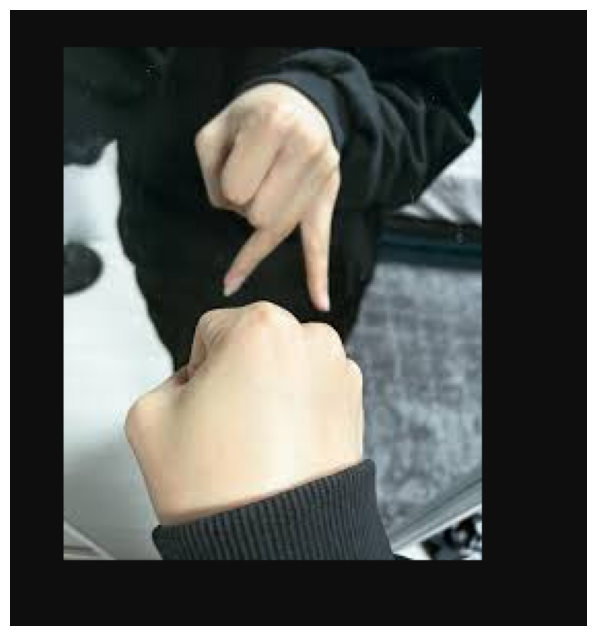

In [11]:
import cv2
import matplotlib.pyplot as plt

filename = '거울.png'
result = CLIENT.infer(filename, model_id="rock-paper-scissors-sxsw/14")
img = cv2.imread(filename)

for pred in result["predictions"]:
    x, y = pred['x'], pred['y']
    width, height = pred['width'], pred['height']
    conf = pred['confidence']
    cls = pred['class']
    x1, y1 = int(x-width/2), int(y-height/2)
    x2, y2 = int(x+width/2), int(y+height/2)
    cv2.rectangle(img, (x1,y1), (x2, y2), (0,0,255), 2)
    cv2.putText(img, f'{cls} {conf:.4f}', (x1,y1), cv2.FONT_HERSHEY_PLAIN, 2, (0,0,255))

plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()